# Bandit plotting
The purpose of this notebook is to plot the preliminary results on the simple single-bandit task.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd


In [2]:
# Move up to main repo directory
import os
os.chdir("../..") # ONLY RUN THIS ONCE

In [3]:
## Load CSV file from file path string

def load_csv(file_path):
    """Load a CSV file and return a pandas DataFrame."""
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded CSV file: {file_path}")
        return df
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None

### CSV Conversion (OLD)

In [ ]:
## Create separate DataFrames for regret, cum_reward, total_reward, and percent_optimal

def process_csv_data(df):
    """Process the CSV data into separate DataFrames for regret, cumulative reward, total reward, and percent optimal.
    Keeps the subfolder name as a column in each DataFrame."""
    step_regret_cols = [col for col in df.columns if 'step_regret' in col]
    step_reward_cols = [col for col in df.columns if 'step_reward' in col]
    cum_regret_cols = [col for col in df.columns if 'cum_regret' in col]
    cum_reward_cols = [col for col in df.columns if 'cum_reward' in col]
    optimal_actions_cols = [col for col in df.columns if 'reward_optimal_actions']
    sem_opt_actions_cols = [col for col in df.columns if 'sem_optimal_actions' in col]

    # Ensure subfolder column is included
    subfolder_col = ['subfolder'] if 'subfolder' in df.columns else []

    step_regret_df = df[subfolder_col + step_regret_cols]
    step_reward_df = df[subfolder_col + step_reward_cols]
    cum_regret_df = df[subfolder_col + cum_regret_cols]
    cum_reward_df = df[subfolder_col + cum_reward_cols]
    percent_optimal_df = df[subfolder_col + percent_optimal_cols]

    return {
        'step_regret': step_regret_df, 
        'step_reward': step_reward_df, 
        'cum_regret': cum_regret_df, 
        'cum_reward': cum_reward_df, 
        'percent_optimal': percent_optimal_df
    }

# Example usage:
# df = load_csv("path_to_csv")
# regret_df, cum_reward_df, total_reward_df, percent_optimal_df = process_csv_data(df)

In [6]:
def add_match_column(df, column_name, substrings, new_column_name):
    """
    Add a new column to the DataFrame based on substring matches in a specific column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The column to search for substrings.
        substrings (list): List of substrings to match.
        new_column_name (str): The name of the new column.

    Returns:
        pd.DataFrame: The DataFrame with the new column added.

    Raises:
        ValueError: If there are rows with no matches or multiple matches.
    """
    def find_match(value):
        # Sort substrings by length in descending order to prioritize longer matches
        sorted_substrings = sorted(substrings, key=len, reverse=True)
        matches = [substring for substring in sorted_substrings if substring in value]
        if len(matches) > 1:
            # Ensure only the longest substring match is considered
            matches = [match for match in matches if not any(other in match for other in matches if other != match)]
        if len(matches) > 1:
            raise ValueError(f"Multiple matches found for value '{value}': {matches}")
        if len(matches) == 0:
            raise ValueError(f"No match found for value '{value}'")
        return matches[0]

    # Use .loc to explicitly assign values
    df = df.copy()  # Ensure we are working with a copy
    df.loc[:, new_column_name] = df[column_name].apply(find_match)
    return df

### Lookup Maps for Plots

In [27]:
rewards_per_scale = {
    'high_scale': [75,50,25],
    'low_scale': [0.75,0.5,0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale': [-0.25, -0.5, -0.75]
}

## Plotting

In [ ]:
## Great a line graph where each line is labelled accordingly
def draw_line_plot(results_dict, title, x_lab="Turn", y_lab="Reward"):
    # Initialize the plot
    plt.figure(figsize=(10, 6))
    
    # We expect results_dict to be keys (used in the legend) and a list of values to plot at each timestep
    for label, rewards in results_dict.items():
        plt.plot(rewards, label=label)  # Plot each reward list with its corresponding label
    
    # Apply title and labels from arguments
    plt.title(title)
    plt.xlabel(x_lab)
    plt.ylabel(y_lab)
    
    # Add a legend to differentiate the lines
    plt.legend()
    
    # Display the plot
    plt.show()

In [24]:
def plot_metric_with_std(input_df, metric_name, subplot_col, legend_col, title="Please Add a Title"):
    """
    Plot a line graph with mean and standard deviation for a given metric, creating subplots for each keyword in subplot_keywords.

    Args:
        input_df (pd.DataFrame): The input DataFrame containing the data to plot.
        metric_name (str): The metric name to plot (e.g., 'reward', 'regret'). 
        subplot_keywords (List[str]): The column (must be exactly 1) to use to separate the rows between subplots.
        legend_keywords (List[str]): The column (must be exactly 1) to use to label the rows in each subplot.
        title (str): The title for the entire figure.

    Returns:
        None
    """

    # Determine the number of subplots
    subplot_keywords = input_df[subplot_col].unique()
    num_subplots = len(subplot_keywords)
    fig, axes = plt.subplots(1, num_subplots, figsize=(5 * num_subplots, 3), sharex=True)
    fig.suptitle(title, fontsize=16)

    if num_subplots == 1:
        axes = [axes]  # Ensure axes is always a list

    ## TODO: Fix this logic to separate based on columns, not keywords
    for ax, subplot_kwd in zip(axes, subplot_keywords):
        # Get rows which contain the subplot keyword in their subfolder name
        filtered_df = input_df[input_df[subplot_col].str.contains(subplot_kwd, na=False)].copy()

        # Create the legend column - just amalgamate the legend columns
        try:
            # Example: Concatenate columns in 'legend_cols' into a new column 'legend'
            filtered_df['legend'] = filtered_df[legend_col]
        except ValueError as e:
            print(e)
            continue

        # Extract the turn numbers from the column names
        turn_numbers = sorted(
            int(col.split('_')[-2]) for col in input_df.columns 
            if col.startswith(f"{metric_name}_") and col.endswith("_mean")
        )

        # Iterate over each unique legend value
        for legend_label in filtered_df['legend'].unique():
            # Filter the DataFrame for the current legend
            legend_df = filtered_df[filtered_df['legend'] == legend_label]

            # Extract the mean and std values for the current legend
            # import pdb; pdb.set_trace()
            # means = legend_df[[f"{metric_name}_{turn}_mean" for turn in turn_numbers]].values
            # stds = legend_df[[f"{metric_name}_{turn}_std" for turn in turn_numbers]].values
            means = legend_df[[f"{metric_name}_{turn}_mean" for turn in turn_numbers]].values.flatten()
            stds = legend_df[[f"{metric_name}_{turn}_std" for turn in turn_numbers]].values.flatten()

            # Plot the mean line
            try:
                ax.plot(turn_numbers, means, label=legend_label)
            except Exception as e:
                print(f"ERROR: {legend_label} {subplot_kwd} {turn_numbers} {means} {filtered_df} {legend_df}", e)

            # Plot the shaded area for std
            ax.fill_between(turn_numbers, means - stds, means + stds, alpha=0.2)

        ## ADD TOPLINE AND BASELINE - NOTE WE ASSUME subplot_kwd is the scale for now
        scale_rewards = rewards_per_scale[subplot_kwd]
        if metric_name == 'cum_regret':
            max_regret = max(scale_rewards) - min(scale_rewards)
            max_regret_list = [max_regret * i for i in range(1, len(turn_numbers) + 1)]
            min_regret_list = [0.0] * len(turn_numbers)
            ax.plot(turn_numbers, max_regret_list, label="Max Regret", color='firebrick', linestyle=':')
            ax.plot(turn_numbers, min_regret_list, label="Min Regret", color='black', linestyle=':')
        elif metric_name == 'cum_reward':
            max_reward = max(scale_rewards)
            min_reward = min(scale_rewards)
            max_reward_list = [max_reward * i for i in range(1, len(turn_numbers) + 1)]
            min_reward_list = [min_reward * i for i in range(1, len(turn_numbers) + 1)]
            ax.plot(turn_numbers, max_reward_list, label="Max Reward", color='firebrick', linestyle=':')
            ax.plot(turn_numbers, min_reward_list, label="Min Reward", color='black', linestyle=':')


        # Add title, labels, and legend to the subplot
        ax.set_title(f"{subplot_kwd.capitalize()} {metric_name.capitalize()}")
        ax.set_xlabel("Turn")
        ax.set_ylabel(metric_name.capitalize())
        ax.legend()

    # Adjust layout to prevent overlap
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Jan 19 - Farm Main Results


Loaded CSV file: experiments/20260118_farm_novar/merged_eval_results.csv


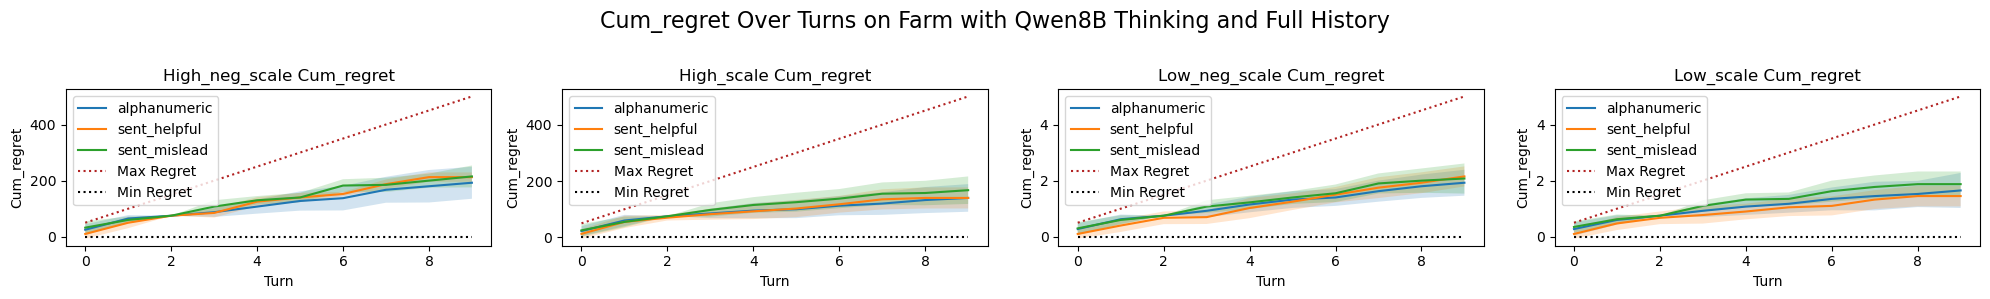

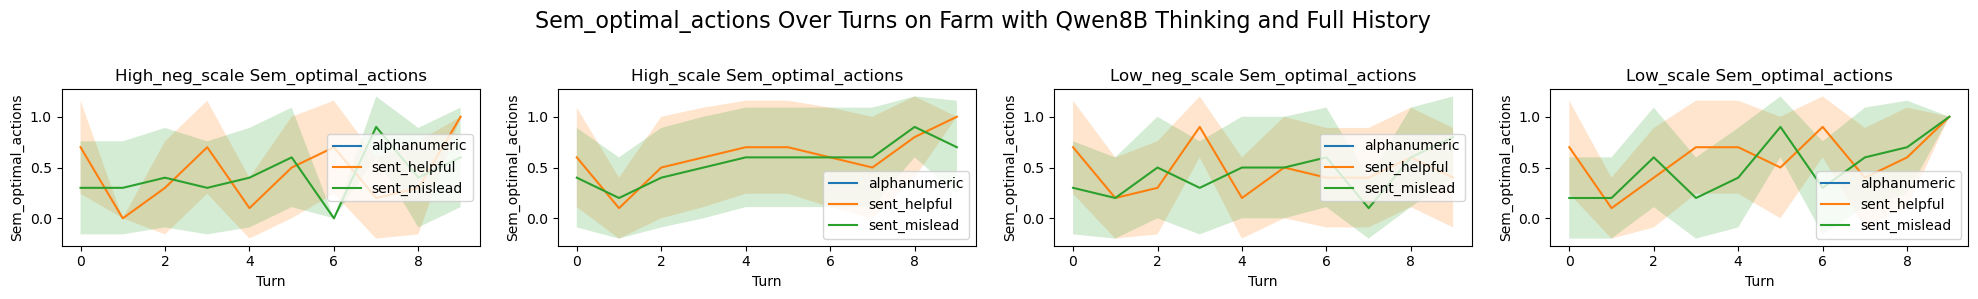

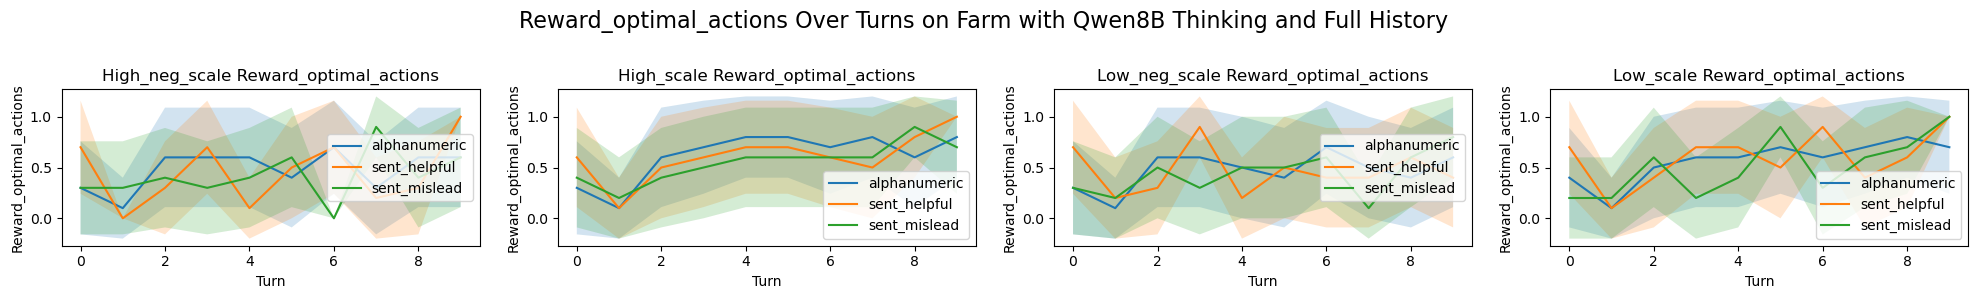

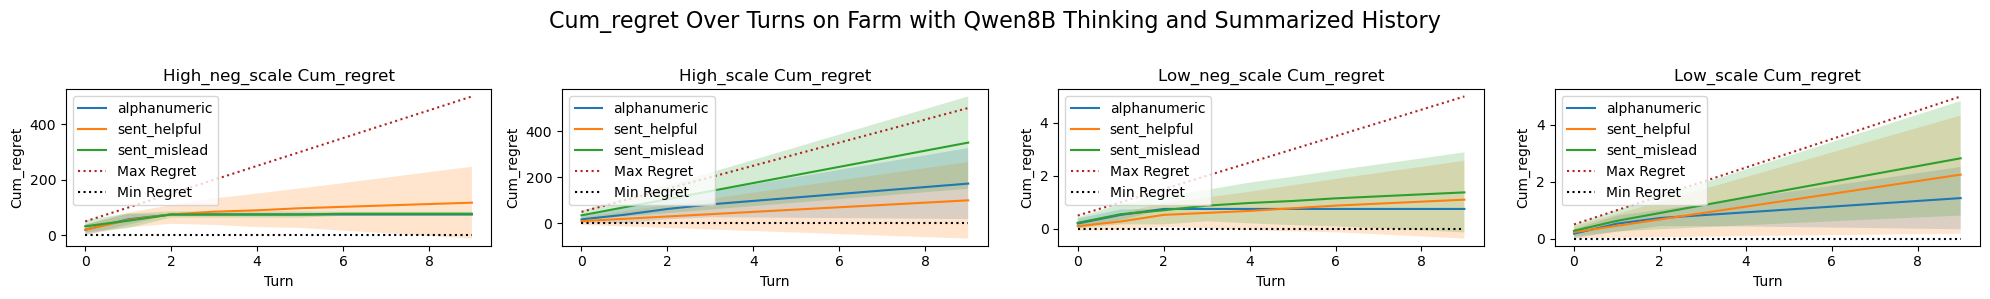

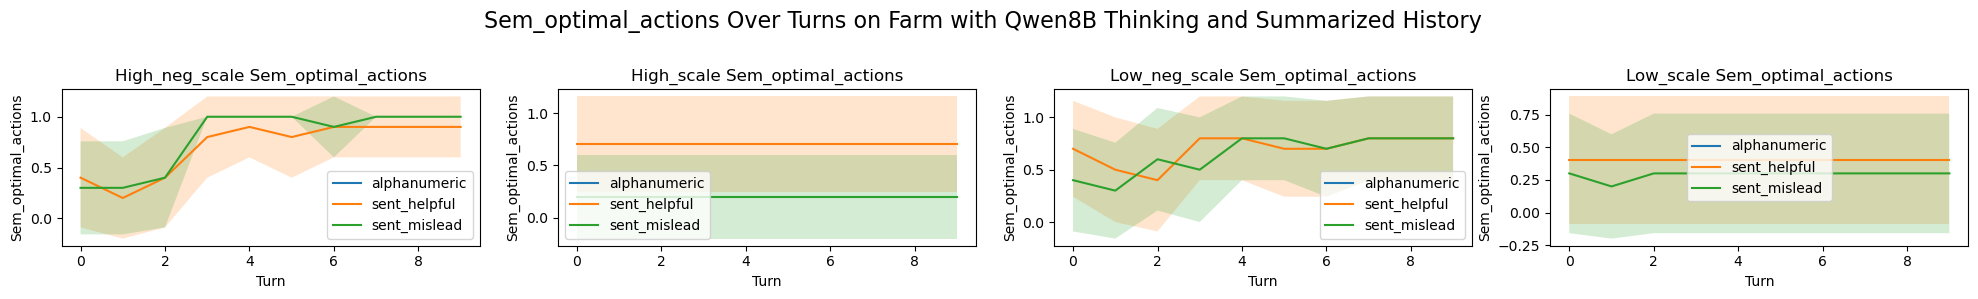

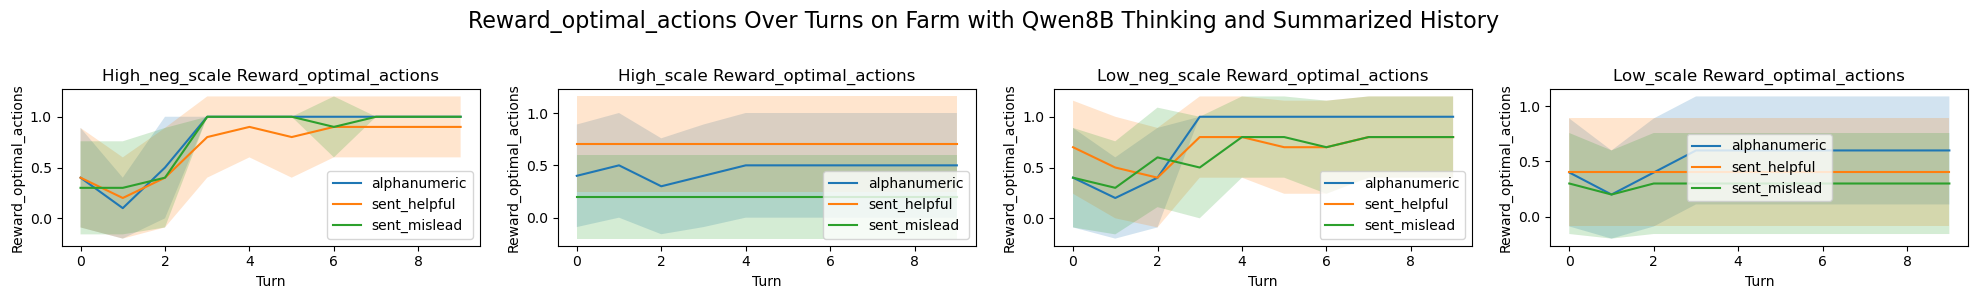

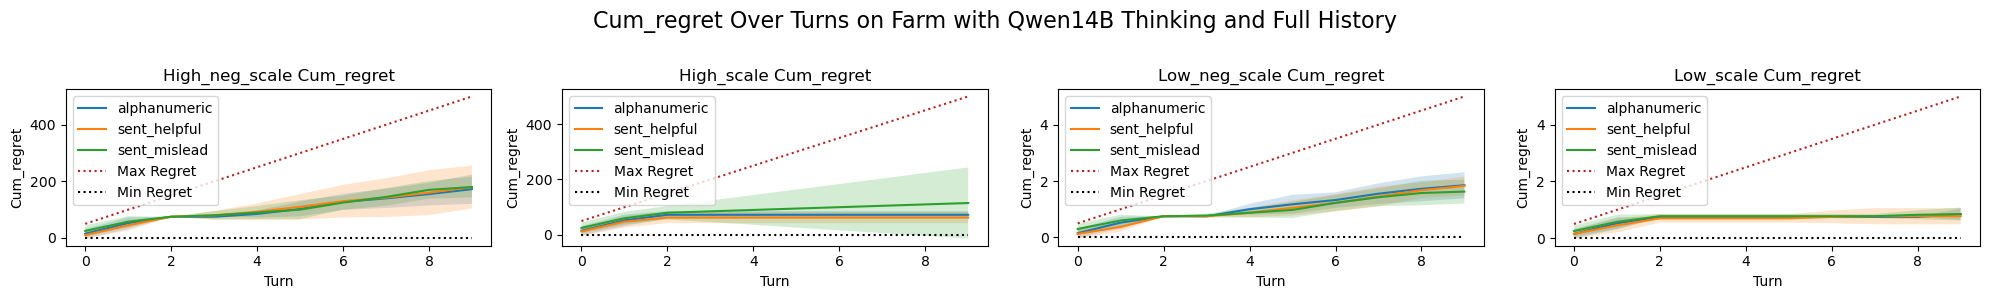

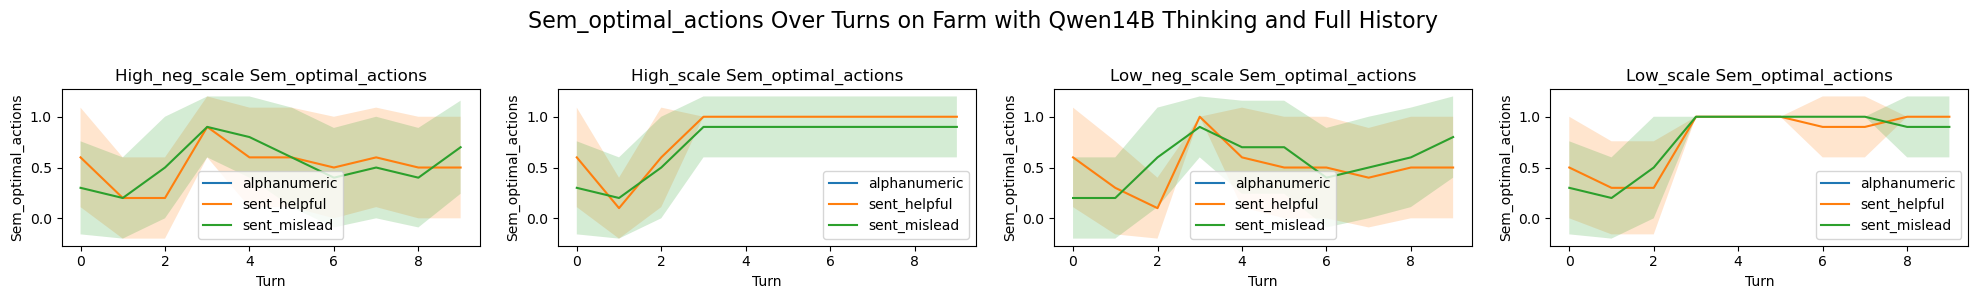

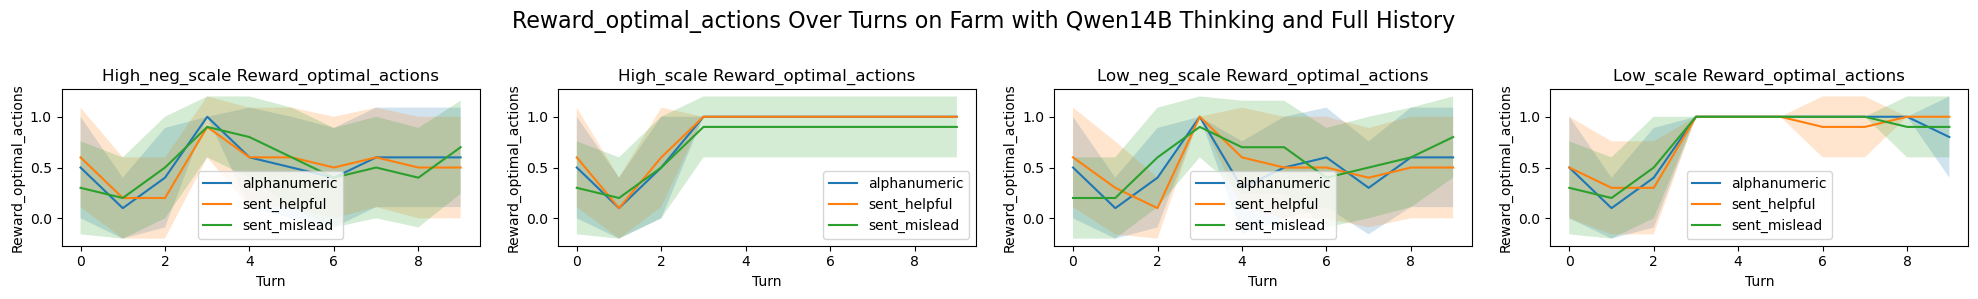

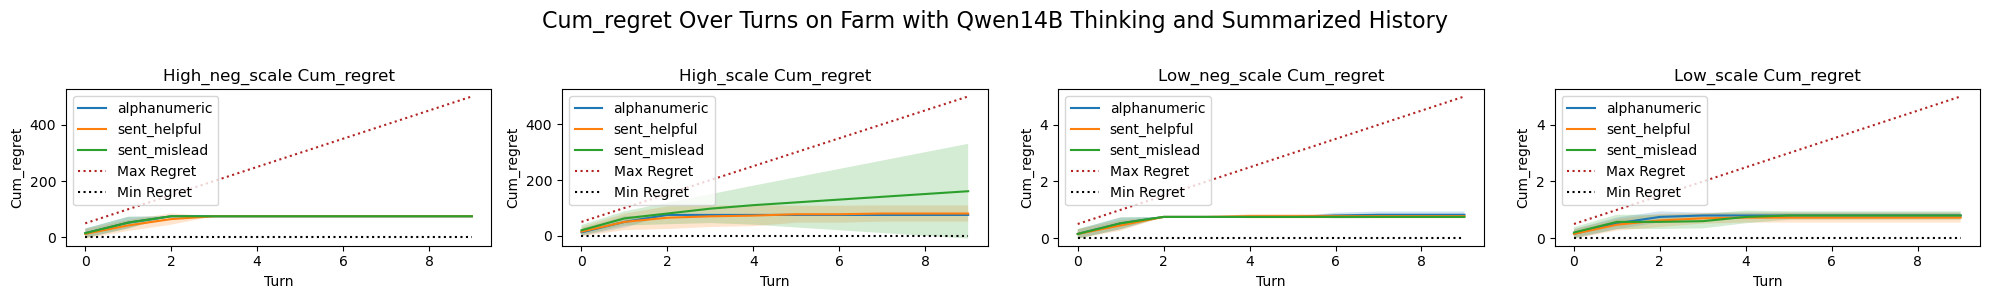

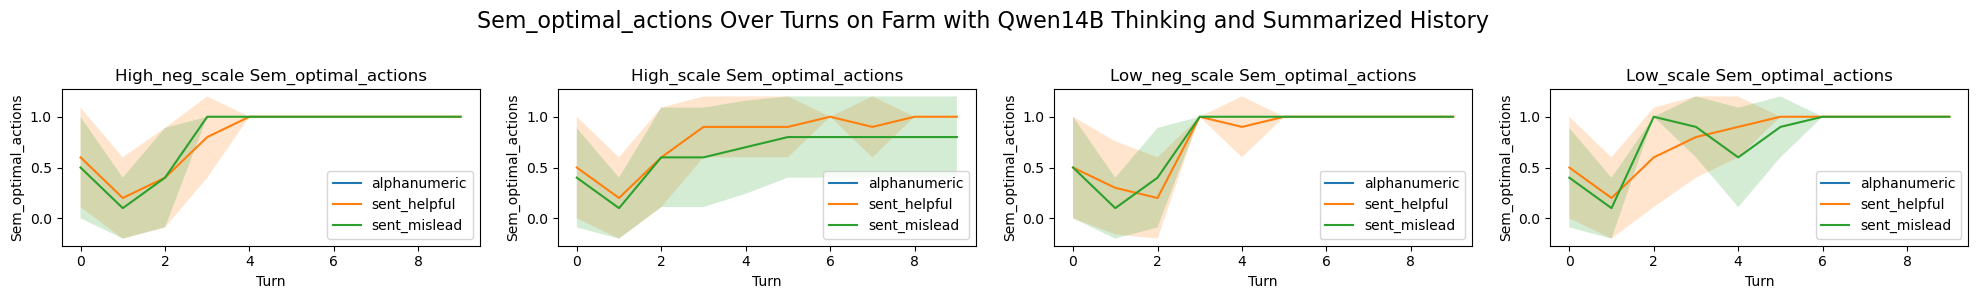

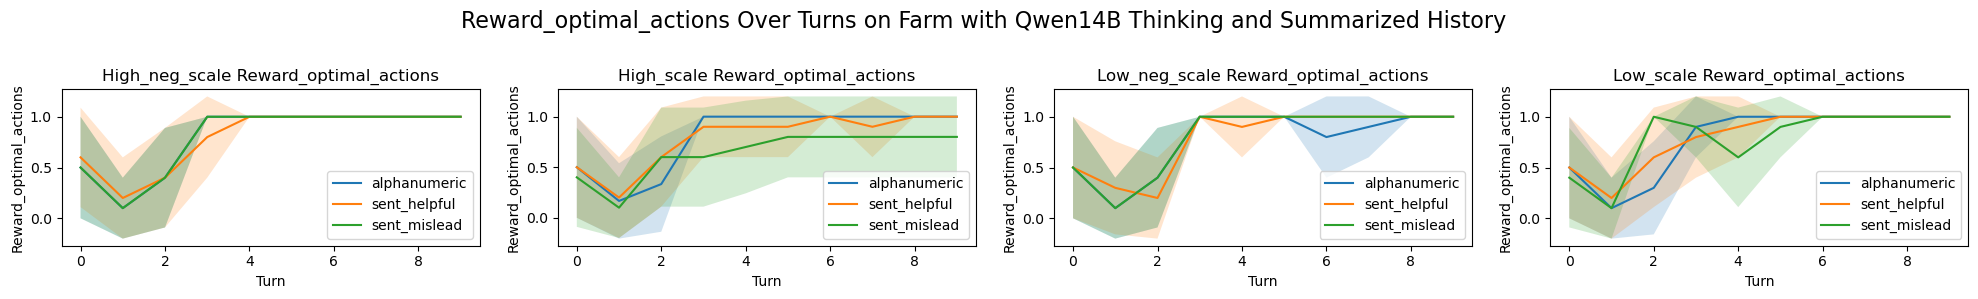

In [28]:
## First, we load in the merged dataframe
eval_path = 'experiments/20260118_farm_novar/merged_eval_results.csv'
results_df = load_csv(eval_path)

subplot_label = 'scale'
legend_label = 'nomenclature'

metrics = ['cum_regret', 'sem_optimal_actions', 'reward_optimal_actions']

for model in results_df['Model'].unique():
    for hist in results_df['History'].unique():
        subset = results_df[(results_df['Model'] == model) & (results_df['History'] == hist)]
        for metric_key in metrics:
            title = f"{metric_key.capitalize()} Over Turns on Farm with {model} Thinking and {hist} History"
            plot_metric_with_std(subset, metric_key, subplot_label, legend_label, title)

## Dec 1 Plotting

In [1]:
eval_path = 'experiments/20251129_farm_qwen3/model_name_Qwen3-4B_time_horizon_8/eval_results.csv'
results_df = load_csv(eval_path)
results_df_dict = process_csv_data(results_df)

legend_keywords = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']
subplot_keywords = ['high_scale', 'low_scale', 'high_neg_scale']

for metric_key, metric_df in results_df_dict.items():
    if metric_key in ['percent_optimal']:
        continue
    title = f"{metric_key.capitalize()} Over Turns on Farm with Qwen3 4B Thinking"
    plot_metric_with_std(metric_df, metric_key, subplot_keywords, legend_keywords, title)
    
# Potential failure modes: keywords cannot be subsets of each other

NameError: name 'load_csv' is not defined

Loaded CSV file: experiments/20251129_farm_qwen3/model_name_Qwen3-8B_time_horizon_8/eval_results.csv


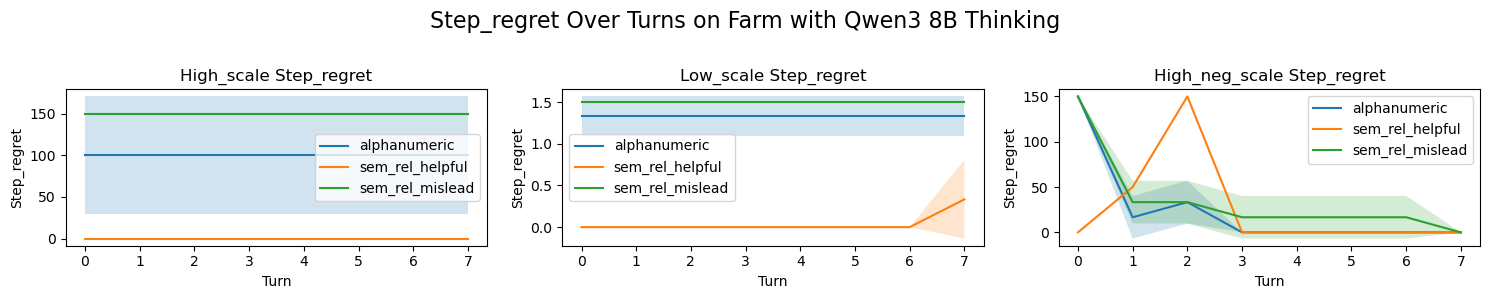

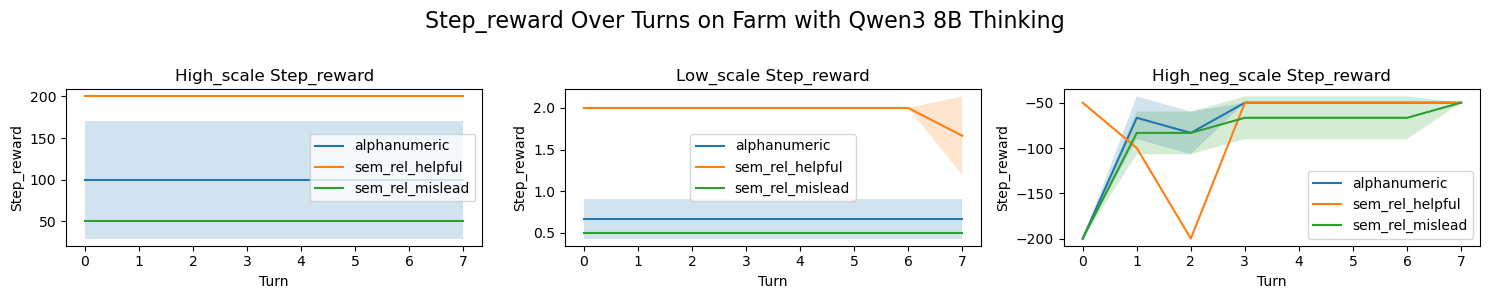

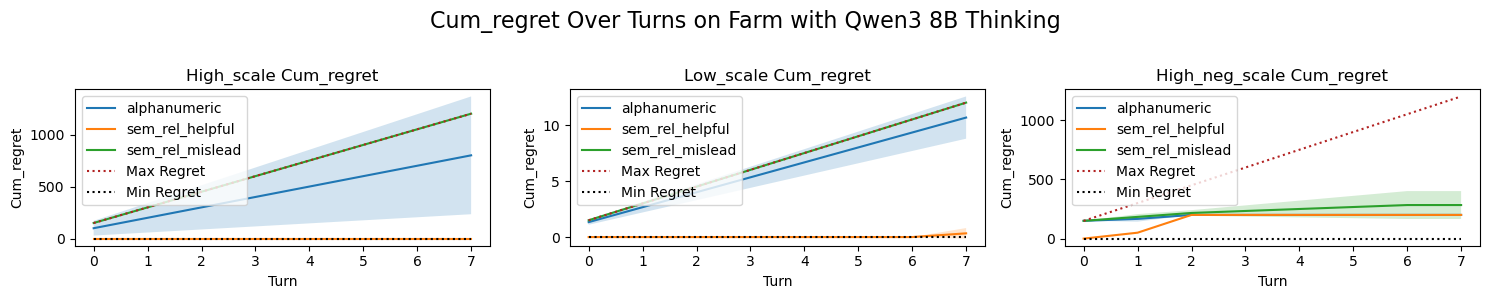

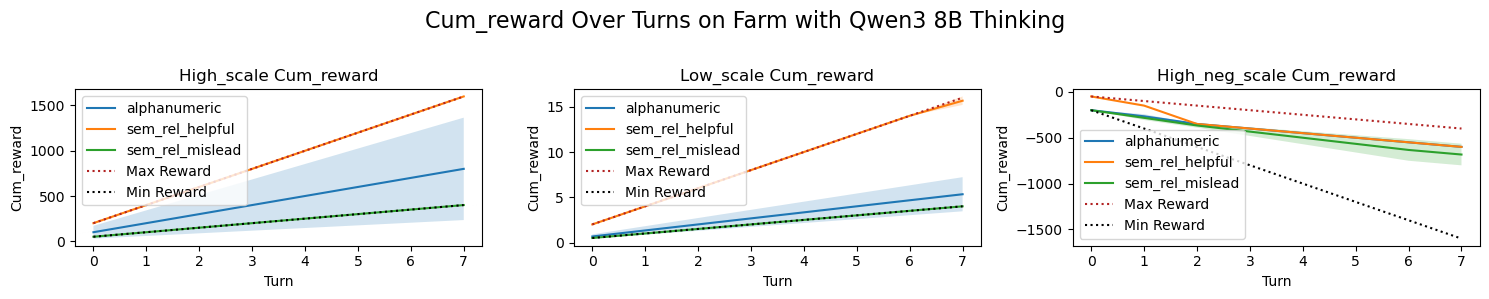

In [ ]:
eval_path = 'experiments/20251129_farm_qwen3/model_name_Qwen3-8B_time_horizon_8/eval_results.csv'
results_df = load_csv(eval_path)
results_df_dict = process_csv_data(results_df)

legend_keywords = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']
subplot_keywords = ['high_scale', 'low_scale', 'high_neg_scale']

for metric_key, metric_df in results_df_dict.items():
    if metric_key in ['percent_optimal']:
        continue
    title = f"{metric_key.capitalize()} Over Turns on Farm with Qwen3 8B Thinking"
    plot_metric_with_std(metric_df, metric_key, subplot_keywords, legend_keywords, title)

Loaded CSV file: experiments/20251129_farm_qwen3/model_name_Qwen3-14B_time_horizon_8/eval_results.csv


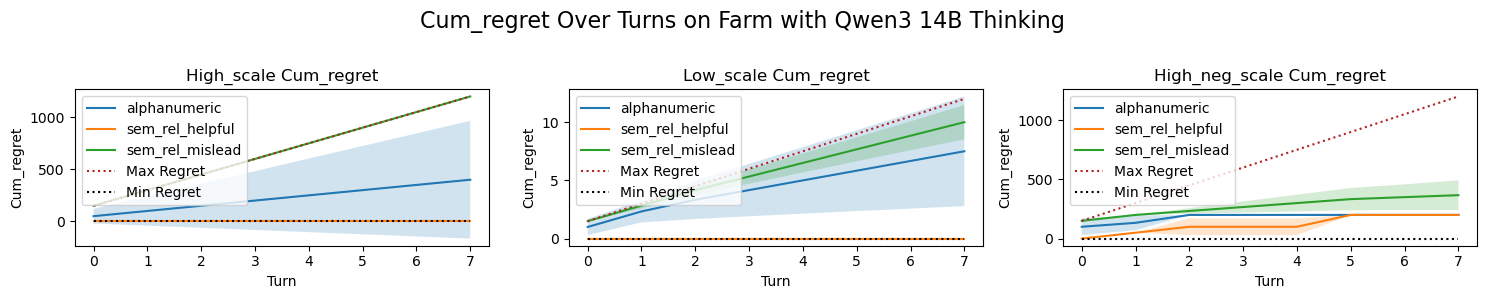

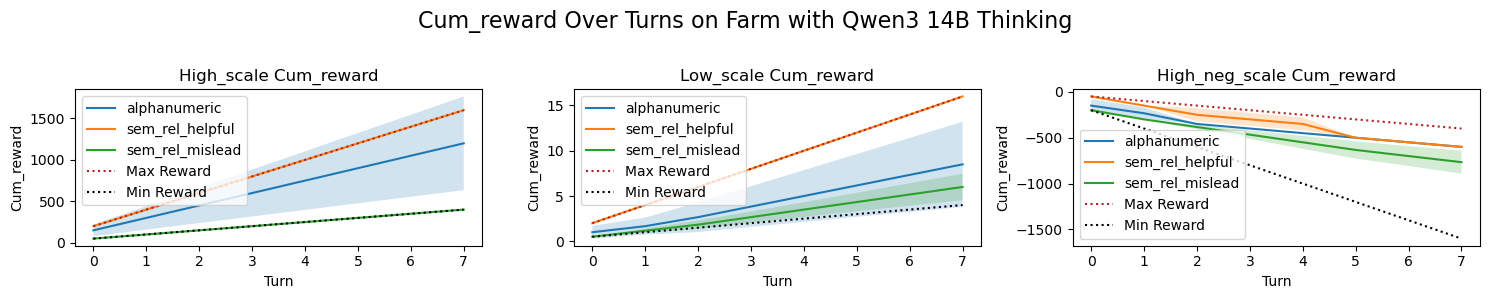

In [ ]:
eval_path = 'experiments/20251129_farm_qwen3/model_name_Qwen3-14B_time_horizon_8/eval_results.csv'
results_df = load_csv(eval_path)
results_df_dict = process_csv_data(results_df)

legend_keywords = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']
subplot_keywords = ['high_scale', 'low_scale', 'high_neg_scale']

for metric_key, metric_df in results_df_dict.items():
    if metric_key in ['percent_optimal', 'step_regret', 'step_reward']:
        continue
    title = f"{metric_key.capitalize()} Over Turns on Farm with Qwen3 14B Thinking"
    plot_metric_with_std(metric_df, metric_key, subplot_keywords, legend_keywords, title)

## Comparing History Passing

What am I trying to show here? Do the different history prompting styles have an impact on model performance? So we'll just plot all of them and compare side by side I guess?

In [13]:
eval_paths = {
    '8B_actionhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_actionhist/eval_results.csv',
    '8B_fullhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_fullhist/eval_results.csv',
    '8B_summhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_summhist/eval_results.csv',
    '14B_actionhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_actionhist/eval_results.csv',
    '14B_fullhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_fullhist/eval_results.csv',
    '14B_summhist': 'experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_summhist/eval_results.csv',
}

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_actionhist/eval_results.csv


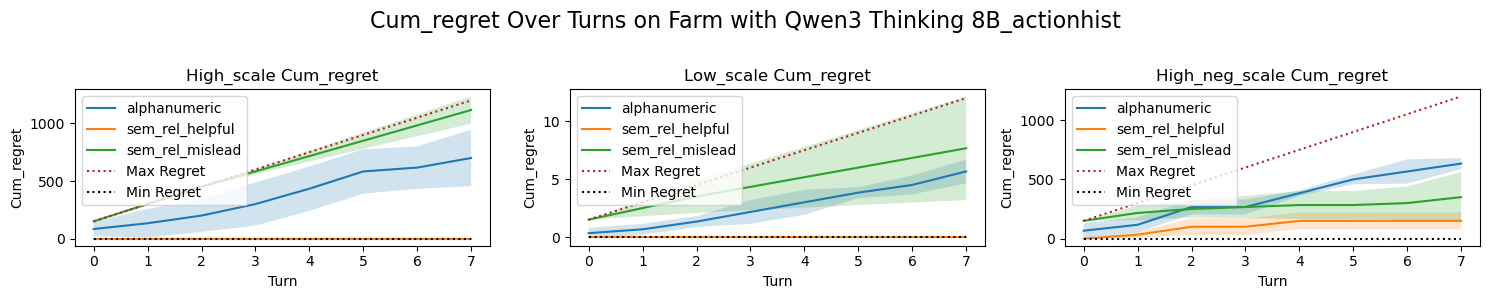

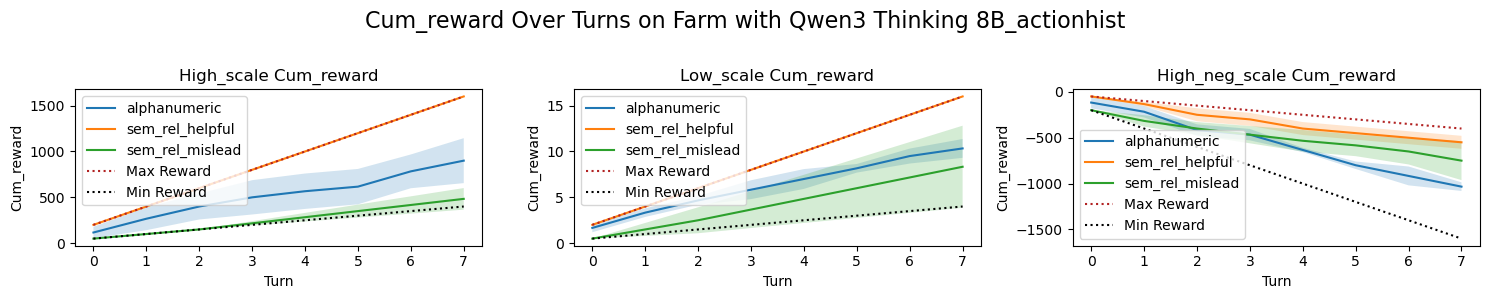

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_fullhist/eval_results.csv


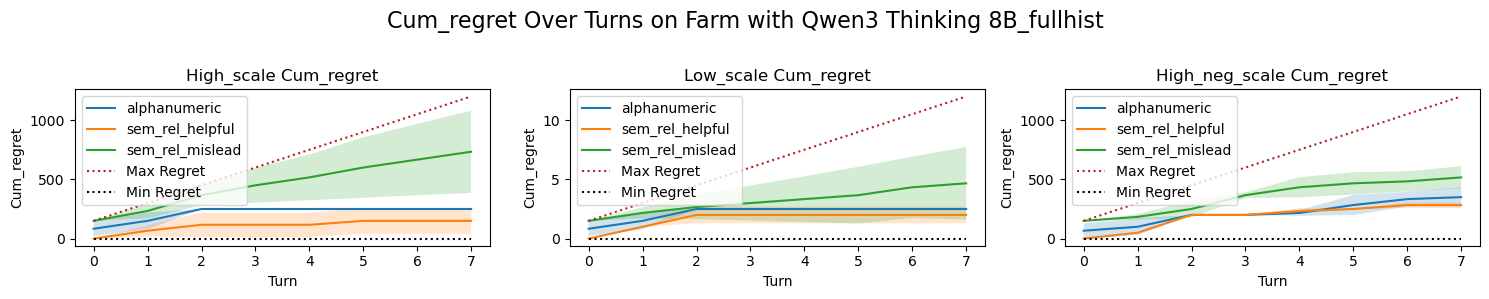

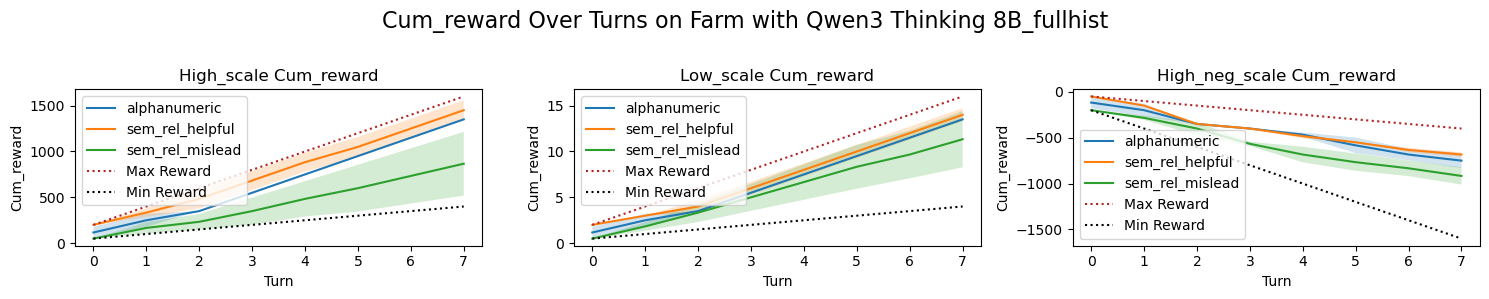

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-8B_time_horizon_8_think_budget_think_budget_150_200_prompt_summhist/eval_results.csv


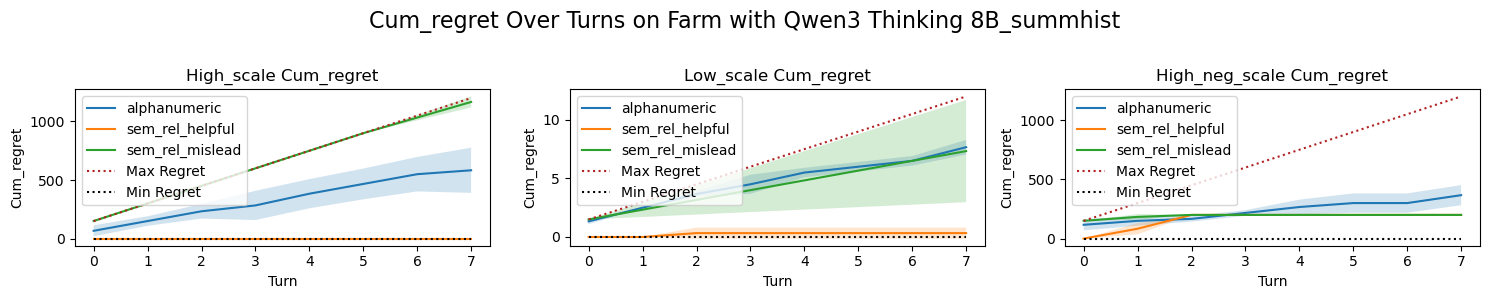

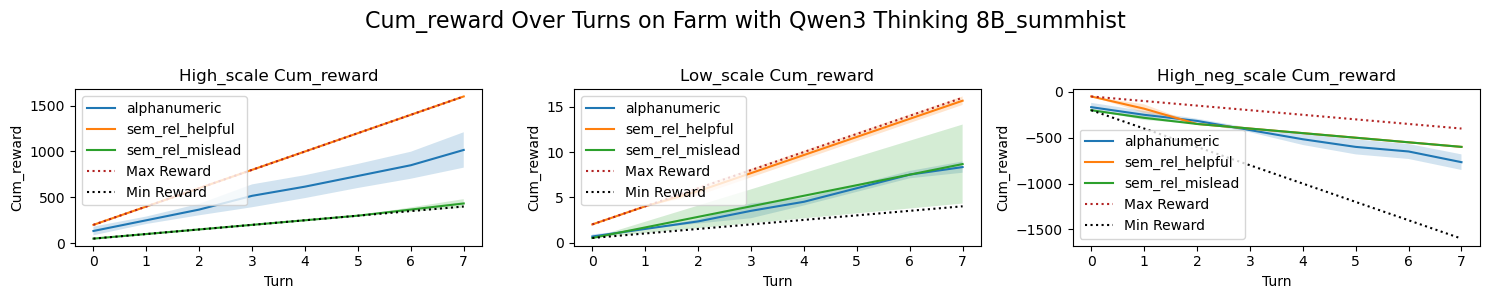

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_actionhist/eval_results.csv


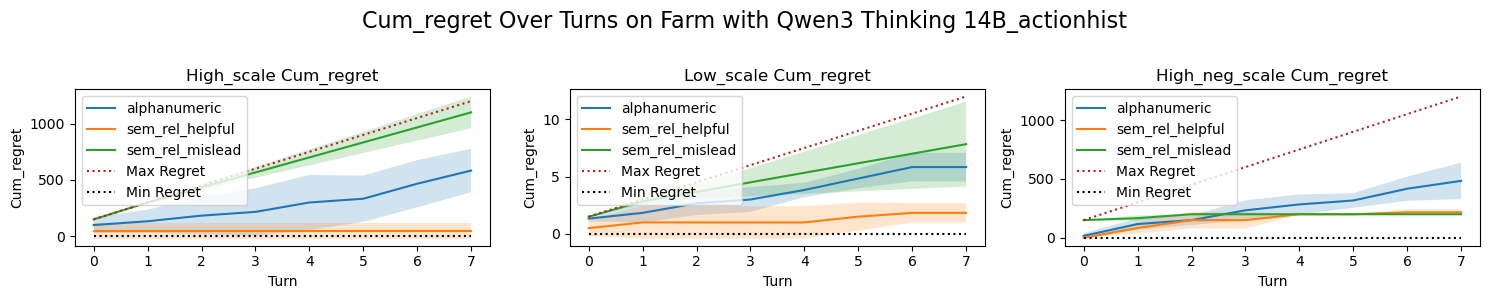

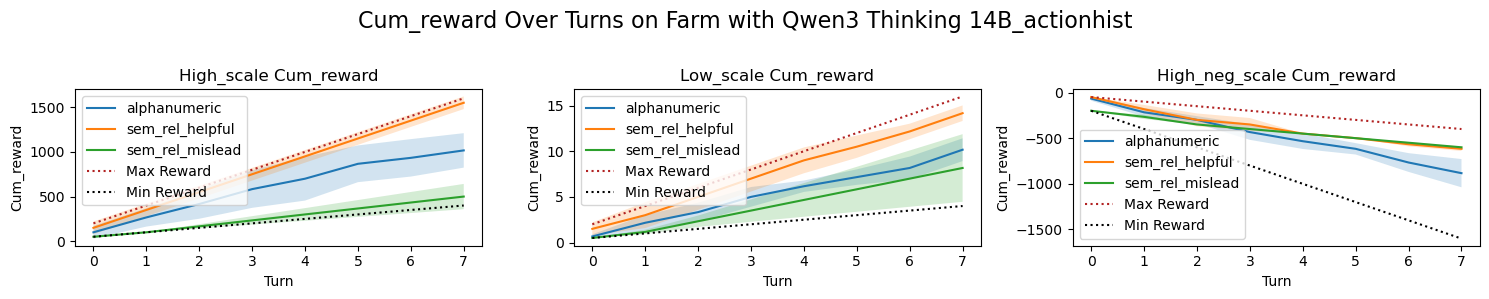

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_fullhist/eval_results.csv


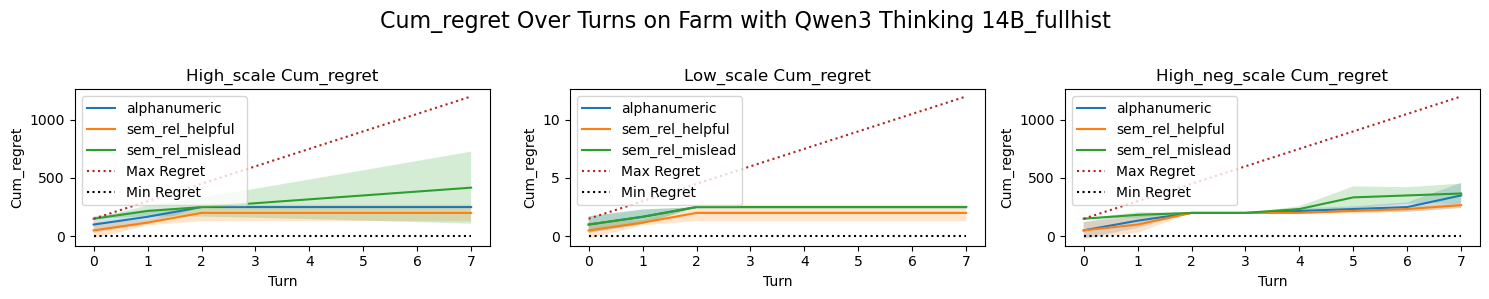

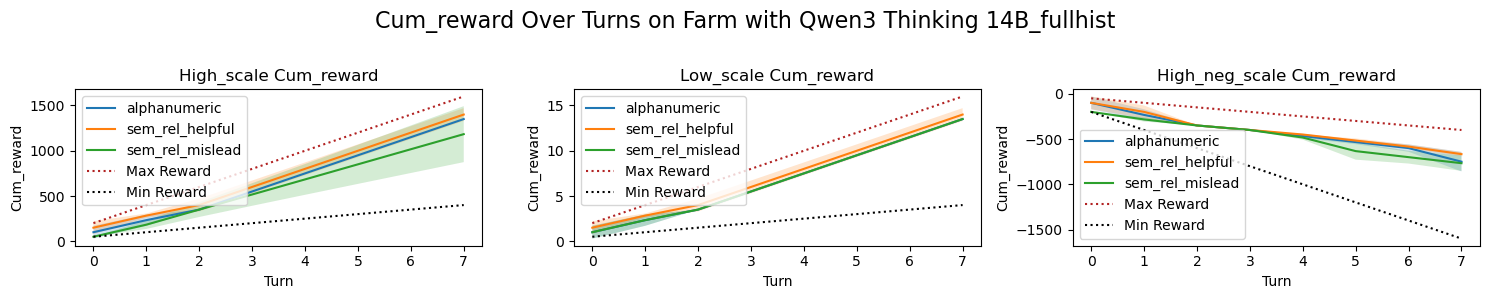

Loaded CSV file: experiments/20251207_prompt_testing/model_name_Qwen3-14B_time_horizon_8_think_budget_think_budget_150_200_prompt_summhist/eval_results.csv


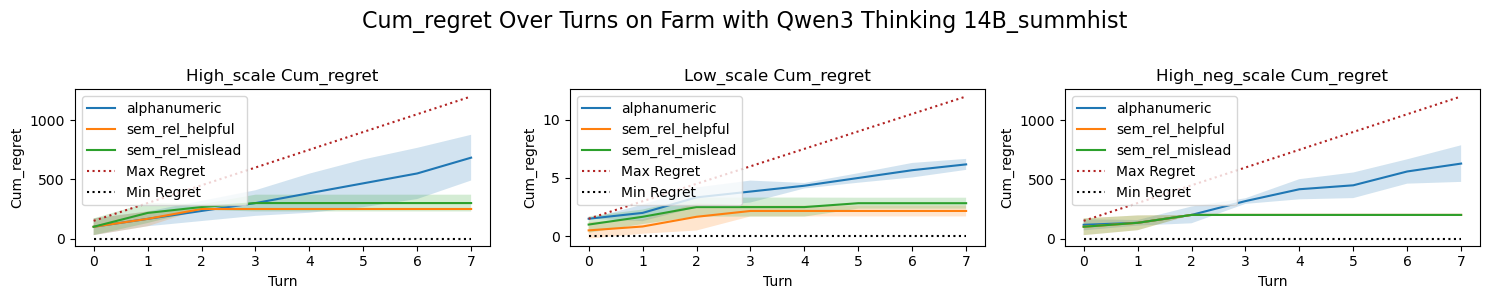

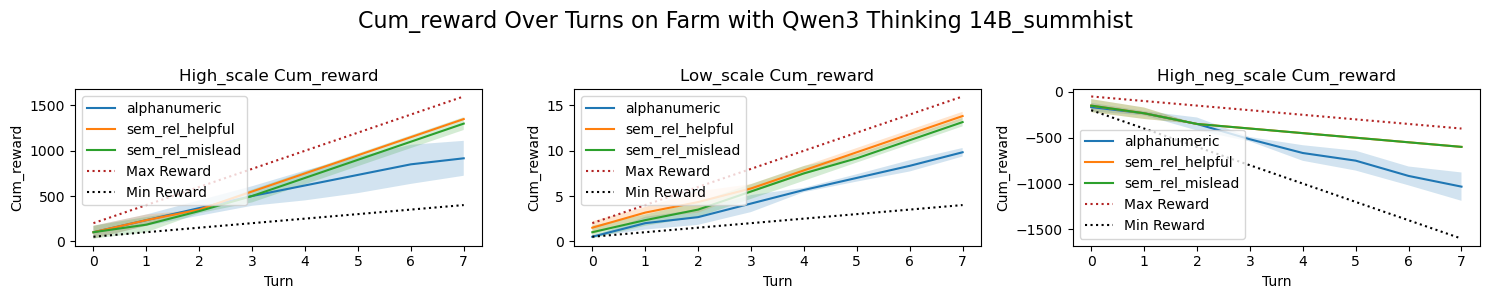

In [14]:
for eval_path_name, eval_path in eval_paths.items():
    results_df = load_csv(eval_path)
    results_df_dict = process_csv_data(results_df)

    legend_keywords = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']
    subplot_keywords = ['high_scale', 'low_scale', 'high_neg_scale']

    for metric_key, metric_df in results_df_dict.items():
        if metric_key in ['percent_optimal', 'step_regret', 'step_reward']:
            continue
        title = f"{metric_key.capitalize()} Over Turns on Farm with Qwen3 Thinking {eval_path_name}"
        plot_metric_with_std(metric_df, metric_key, subplot_keywords, legend_keywords, title)

## Dec 10 - Scale vs Arm Names Total Regret Heatmaps

In [ ]:
## 